<a href="https://colab.research.google.com/github/Absaibro/ProjetoII/blob/main/Analise_Exploratoria_Treinamento_Modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória dos Dados (EDA)

## Projeto de Predição de Evasão Acadêmica

### Objetivo

Esta etapa tem como objetivo compreender o comportamento dos dados antes da construção dos modelos de Machine Learning.

A análise exploratória permite identificar padrões, inconsistências, valores ausentes e possíveis relações entre as variáveis, auxiliando na seleção dos atributos mais relevantes para a predição da evasão acadêmica.

Os dados utilizados correspondem ao Curso Superior de Tecnologia em Análise e Desenvolvimento de Sistemas (ADS), consolidando informações acadêmicas, financeiras e de frequência.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Configuração padrão
plt.rcParams["figure.figsize"] = (10,5)

## Carregamento da Base de Dados

In [4]:
df = pd.read_excel("base_evasao.xlsx")

print("Quantidade de registros:", len(df))
print("Quantidade de colunas:", len(df.columns))

df.head()

Quantidade de registros: 1219
Quantidade de colunas: 18


,MATRICULA,CODIGO_ALUNO,NOME_ALUNO,CURSO,TURMA,TURNO,MODALIDADE,DATA_MATRICULA,DATA_SAIDA,HISTORICO_SITUACAO_ALUNO,EVASAO,TotalAulas,TotalFaltas,TotalFaltasJustificadas,PercentualFaltas,SaldoDevedor,ParcelasPendentes,PossuiDivida
0,71202368,766488,BRUNO FARIAS NASENTE,CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...,ADS1N20/1,NOITE - N,PRESENCIAL,2020-01-14 00:00:00.000,2020-04-18 00:00:00.000,EVADIDO,1,0,0,0,NaN,1548.65,0,1
1,71801504,1581272,MATHEUS KLUG BITENCOURT,CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...,ADS1N25/2,NOITE - N,PRESENCIAL,2025-08-11 00:00:00.000,NaN,Formado.,0,660,29,0,4.39,0.00,0,0
2,71901127,1674333,JULIA MACHADO FICK,CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...,ADS6N25/2,NOITE - N,PRESENCIAL,2025-08-08 00:00:00.000,NaN,Formado.,0,660,56,0,8.48,0.00,0,0
3,1100002ZB,33946,DARI JUNKER MACHADO,CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...,ADS2M25/2,MANHÃ - M,PRESENCIAL,2025-02-14 00:00:00.000,2025-08-27 00:00:00.000,DESISTENTE,1,264,0,0,0.00,0.00,0,0
4,140901589,514638,JULIA QUEVEDO GRAVE,CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...,ADS3N23/2,NOITE - N,PRESENCIAL,2023-06-15 00:00:00.000,2023-07-14 00:00:00.000,DESISTENTE,1,300,45,0,15.00,2459.58,0,1


## Estrutura da Base

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MATRICULA                 1219 non-null   object 
 1   CODIGO_ALUNO              1219 non-null   int64  
 2   NOME_ALUNO                1219 non-null   object 
 3   CURSO                     1219 non-null   object 
 4   TURMA                     1219 non-null   object 
 5   TURNO                     1219 non-null   object 
 6   MODALIDADE                1219 non-null   object 
 7   DATA_MATRICULA            1150 non-null   object 
 8   DATA_SAIDA                867 non-null    object 
 9   HISTORICO_SITUACAO_ALUNO  1219 non-null   object 
 10  EVASAO                    1219 non-null   int64  
 11  TotalAulas                1219 non-null   int64  
 12  TotalFaltas               1219 non-null   int64  
 13  TotalFaltasJustificadas   1219 non-null   int64  
 14  Percentu

In [6]:
df.describe(include="all")

,MATRICULA,CODIGO_ALUNO,NOME_ALUNO,CURSO,TURMA,TURNO,MODALIDADE,DATA_MATRICULA,DATA_SAIDA,HISTORICO_SITUACAO_ALUNO,EVASAO,TotalAulas,TotalFaltas,TotalFaltasJustificadas,PercentualFaltas,SaldoDevedor,ParcelasPendentes,PossuiDivida
count,1219.0,1.219000e+03,1219,1219,1219,1219,1219,1150,867,1219,1219.000000,1219.000000,1219.000000,1219.000000,1050.000000,1219.000000,1219.000000,1219.000000
unique,1219.0,NaN,1219,1,180,2,1,719,311,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,842400127.0,NaN,ISABELE MACHADO FONTES,CURSO SUPERIOR DE TECNOLOGIA EM ANÁLISE E DESE...,ADS6N22/2,NOITE - N,PRESENCIAL,2026-06-22 00:00:00.000,2022-09-01 00:00:00.000,DESISTENTE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1.0,NaN,1,1219,34,864,1219,13,48,650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.481952e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.703856,355.703856,52.794914,0.446267,19.653676,1403.721575,0.459393,0.475800
std,NaN,5.915589e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.456743,405.070897,70.013491,4.457722,20.367543,2384.298539,1.523419,0.499619
min,NaN,7.500000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.050606e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,80.000000,7.000000,0.000000,5.922500,0.000000,0.000000,0.000000
50%,NaN,1.625500e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,240.000000,28.000000,0.000000,12.555000,0.000000,0.000000,0.000000
75%,NaN,1.886484e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,506.000000,72.000000,0.000000,25.000000,2261.680000,0.000000,1.000000


## Valores Ausentes

In [7]:
nulos = df.isnull().sum()

nulos[nulos > 0]

,0
DATA_MATRICULA,69
DATA_SAIDA,352
PercentualFaltas,169


## Distribuição da Variável Alvo

Nesta etapa é analisada a distribuição dos alunos que permaneceram no curso e dos alunos que evadiram.

Essa análise permite verificar se a base de dados está balanceada ou se existe predominância de uma das classes.

/tmp/ipykernel_1293/2582648885.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Permaneceu","Evadiu"])


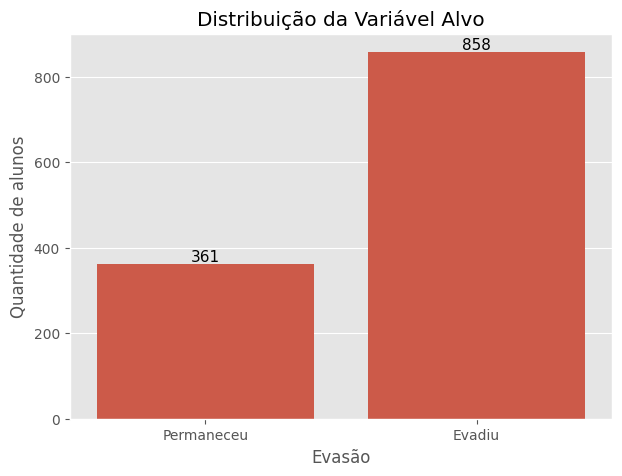

In [8]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="EVASAO")

plt.title("Distribuição da Variável Alvo")
plt.xlabel("Evasão")
plt.ylabel("Quantidade de alunos")

ax.set_xticklabels(["Permaneceu","Evadiu"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.show()

## Percentual de Faltas

Uma das hipóteses do projeto é que alunos com maior percentual de faltas apresentem maior propensão à evasão.

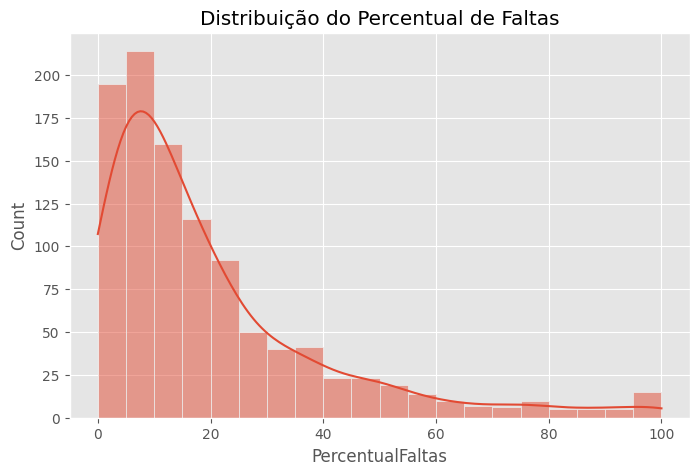

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="PercentualFaltas",
    bins=20,
    kde=True
)

plt.title("Distribuição do Percentual de Faltas")

plt.show()

## Saldo Devedor

Nesta etapa é analisada a distribuição do saldo devedor dos alunos, verificando possíveis concentrações de inadimplência.

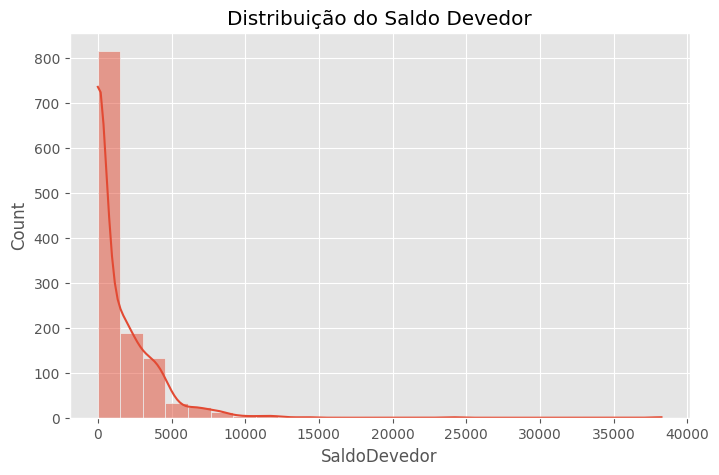

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="SaldoDevedor",
    bins=25,
    kde=True
)

plt.title("Distribuição do Saldo Devedor")

plt.show()

## Parcelas Pendentes

A quantidade de parcelas pendentes pode indicar dificuldades financeiras e contribuir para a evasão acadêmica.

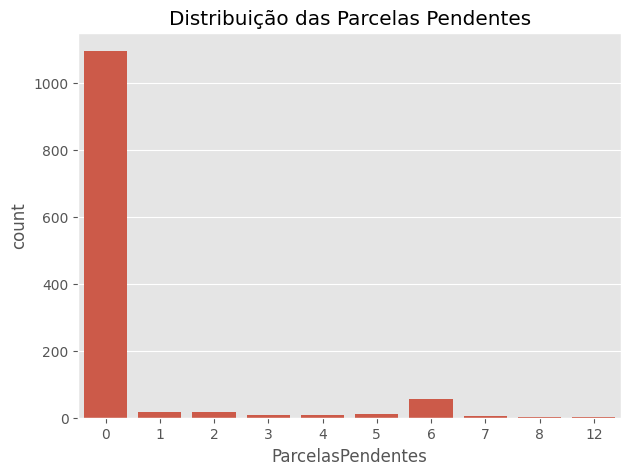

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="ParcelasPendentes"
)

plt.title("Distribuição das Parcelas Pendentes")

plt.show()

## Percentual de Faltas por Situação de Evasão

O objetivo desta análise é verificar se existe diferença no percentual de faltas entre alunos que permaneceram e aqueles que evadiram.

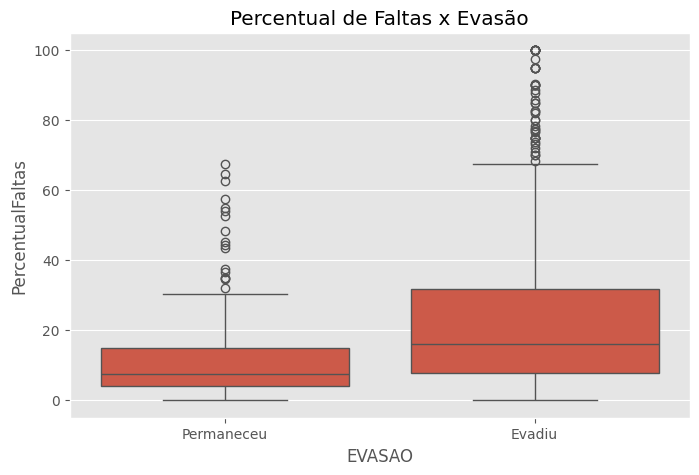

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="EVASAO",
    y="PercentualFaltas"
)

plt.xticks([0,1],["Permaneceu","Evadiu"])

plt.title("Percentual de Faltas x Evasão")

plt.show()

## Saldo Devedor por Situação de Evasão

Compara a distribuição do saldo devedor entre alunos que permaneceram e alunos evadidos.

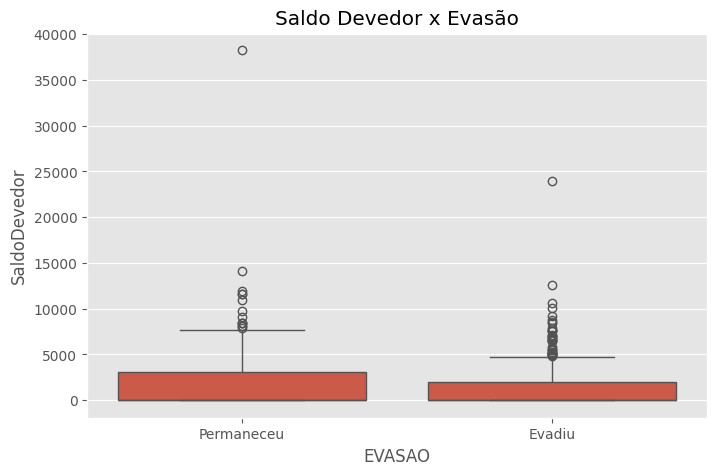

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="EVASAO",
    y="SaldoDevedor"
)

plt.xticks([0,1],["Permaneceu","Evadiu"])

plt.title("Saldo Devedor x Evasão")

plt.show()

# Preparação dos Dados

Nesta etapa os dados são preparados para utilização pelos algoritmos de Machine Learning.

Serão realizadas as seguintes atividades:

- Seleção das variáveis;
- Conversão das variáveis categóricas;
- Tratamento dos valores ausentes;
- Separação entre variáveis preditoras e variável alvo.

In [14]:
# Criando uma cópia da base

base_ml = df.copy()

# Padroniza os textos removendo espaços extras

base_ml["TURMA"] = base_ml["TURMA"].astype(str).str.strip()
base_ml["TURNO"] = base_ml["TURNO"].astype(str).str.strip()
base_ml["MODALIDADE"] = base_ml["MODALIDADE"].astype(str).str.strip()

## Remoção de Colunas Não Utilizadas

Algumas colunas possuem apenas função de identificação e não contribuem para o treinamento do modelo.

In [15]:
colunas_remover = [

    "MATRICULA",
    "CODIGO_ALUNO",
    "NOME_ALUNO",
    "CURSO",
    "DATA_MATRICULA",
    "DATA_SAIDA",
    "HISTORICO_SITUACAO_ALUNO"

]

base_ml = base_ml.drop(columns=colunas_remover, errors="ignore")

base_ml.head()

,TURMA,TURNO,MODALIDADE,EVASAO,TotalAulas,TotalFaltas,TotalFaltasJustificadas,PercentualFaltas,SaldoDevedor,ParcelasPendentes,PossuiDivida
0,ADS1N20/1,NOITE - N,PRESENCIAL,1,0,0,0,NaN,1548.65,0,1
1,ADS1N25/2,NOITE - N,PRESENCIAL,0,660,29,0,4.39,0.00,0,0
2,ADS6N25/2,NOITE - N,PRESENCIAL,0,660,56,0,8.48,0.00,0,0
3,ADS2M25/2,MANHÃ - M,PRESENCIAL,1,264,0,0,0.00,0.00,0,0
4,ADS3N23/2,NOITE - N,PRESENCIAL,1,300,45,0,15.00,2459.58,0,1


## Conversão das Variáveis Categóricas

Os algoritmos de Machine Learning trabalham com dados numéricos.

Nesta etapa as variáveis categóricas são convertidas para representação numérica utilizando LabelEncoder.

In [16]:
from sklearn.preprocessing import LabelEncoder

# Um encoder para cada variável categórica
encoder_turma = LabelEncoder()
encoder_turno = LabelEncoder()
encoder_modalidade = LabelEncoder()

base_ml["TURMA"] = encoder_turma.fit_transform(
    base_ml["TURMA"].astype(str)
)

base_ml["TURNO"] = encoder_turno.fit_transform(
    base_ml["TURNO"].astype(str)
)

base_ml["MODALIDADE"] = encoder_modalidade.fit_transform(
    base_ml["MODALIDADE"].astype(str)
)

In [17]:
print(encoder_turma.classes_)

['ADS1M19/1' 'ADS1M19/2' 'ADS1M20/1' 'ADS1M21/1' 'ADS1M21/2' 'ADS1M22/1'
 'ADS1M22/2' 'ADS1M23/1' 'ADS1M23/2' 'ADS1M24/1' 'ADS1M24/2' 'ADS1M25/1'
 'ADS1M25/2' 'ADS1M26/1' 'ADS1M26/2' 'ADS1N19/1' 'ADS1N19/2' 'ADS1N20/1'
 'ADS1N20/2' 'ADS1N21/1' 'ADS1N21/2' 'ADS1N22/1' 'ADS1N22/2' 'ADS1N23/1'
 'ADS1N23/2' 'ADS1N24/1' 'ADS1N24/2' 'ADS1N25/1' 'ADS1N25/2' 'ADS1N26/1'
 'ADS1N26/2' 'ADS2M19/1' 'ADS2M19/2' 'ADS2M20/1' 'ADS2M20/2' 'ADS2M21/1'
 'ADS2M21/2' 'ADS2M22/1' 'ADS2M22/2' 'ADS2M23/1' 'ADS2M23/2' 'ADS2M24/1'
 'ADS2M24/2' 'ADS2M25/1' 'ADS2M25/2' 'ADS2M26/1' 'ADS2M26/2' 'ADS2N19/1'
 'ADS2N19/2' 'ADS2N20/1' 'ADS2N20/2' 'ADS2N21/1' 'ADS2N21/2' 'ADS2N22/1'
 'ADS2N22/2' 'ADS2N23/1' 'ADS2N23/2' 'ADS2N24/1' 'ADS2N24/2' 'ADS2N25/1'
 'ADS2N25/2' 'ADS2N26/1' 'ADS2N26/2' 'ADS3M19/1' 'ADS3M19/2' 'ADS3M20/1'
 'ADS3M20/2' 'ADS3M21/1' 'ADS3M21/2' 'ADS3M22/1' 'ADS3M22/2' 'ADS3M23/1'
 'ADS3M23/2' 'ADS3M24/1' 'ADS3M24/2' 'ADS3M25/1' 'ADS3M25/2' 'ADS3M26/1'
 'ADS3M26/2' 'ADS3N19/1' 'ADS3N19/2' 'ADS3N20/1' 'A

## Separação entre Variáveis Preditoras e Variável Alvo

In [18]:
X = base_ml.drop(columns=["EVASAO"])

y = base_ml["EVASAO"]

print(X.shape)

print(y.shape)

(1219, 10)
(1219,)


## Divisão entre Treinamento e Teste

A base foi dividida em:

- 70% para treinamento

- 30% para teste

utilizando estratificação da variável alvo.

In [19]:
# Tratamento dos valores nulos

print("Valores nulos antes:")
print(X.isnull().sum())

# Preenche PercentualFaltas com a mediana
X["PercentualFaltas"] = X["PercentualFaltas"].fillna(
    X["PercentualFaltas"].median()
)

print("\nValores nulos depois:")
print(X.isnull().sum())

Valores nulos antes:
TURMA                        0
TURNO                        0
MODALIDADE                   0
TotalAulas                   0
TotalFaltas                  0
TotalFaltasJustificadas      0
PercentualFaltas           169
SaldoDevedor                 0
ParcelasPendentes            0
PossuiDivida                 0
dtype: int64

Valores nulos depois:
TURMA                      0
TURNO                      0
MODALIDADE                 0
TotalAulas                 0
TotalFaltas                0
TotalFaltasJustificadas    0
PercentualFaltas           0
SaldoDevedor               0
ParcelasPendentes          0
PossuiDivida               0
dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(853, 10)
(366, 10)


# Modelo 1 - Regressão Logística

A Regressão Logística é um dos algoritmos mais utilizados para problemas de classificação binária.

Neste projeto ela será utilizada como modelo base para prever a evasão acadêmica.

In [21]:
from sklearn.preprocessing import StandardScaler

# Padroniza apenas os dados de entrada
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [23]:
previsoes_lr = modelo_lr.predict(X_test_scaled)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print(f"Accuracy : {accuracy_score(y_test, previsoes_lr):.4f}")
print(f"Precision: {precision_score(y_test, previsoes_lr):.4f}")
print(f"Recall   : {recall_score(y_test, previsoes_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, previsoes_lr):.4f}")

Accuracy : 0.8415
Precision: 0.8788
Recall   : 0.8992
F1 Score : 0.8889


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, previsoes_lr))

              precision    recall  f1-score   support

           0       0.75      0.70      0.72       108
           1       0.88      0.90      0.89       258

    accuracy                           0.84       366
   macro avg       0.81      0.80      0.81       366
weighted avg       0.84      0.84      0.84       366



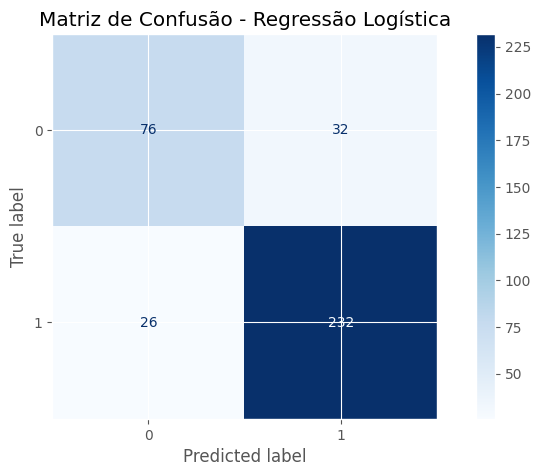

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    previsoes_lr,
    cmap="Blues"
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

# Modelo 2 - Árvore de Decisão

A Árvore de Decisão é um algoritmo supervisionado que cria regras de decisão para classificar os alunos em relação à evasão acadêmica.

In [27]:
from sklearn.tree import DecisionTreeClassifier

modelo_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [28]:
previsoes_tree = modelo_tree.predict(X_test)

In [29]:
print(f"Accuracy : {accuracy_score(y_test, previsoes_tree):.4f}")
print(f"Precision: {precision_score(y_test, previsoes_tree):.4f}")
print(f"Recall   : {recall_score(y_test, previsoes_tree):.4f}")
print(f"F1 Score : {f1_score(y_test, previsoes_tree):.4f}")

Accuracy : 0.8743
Precision: 0.9206
Recall   : 0.8992
F1 Score : 0.9098


In [30]:
print(classification_report(y_test, previsoes_tree))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       108
           1       0.92      0.90      0.91       258

    accuracy                           0.87       366
   macro avg       0.85      0.86      0.85       366
weighted avg       0.88      0.87      0.88       366



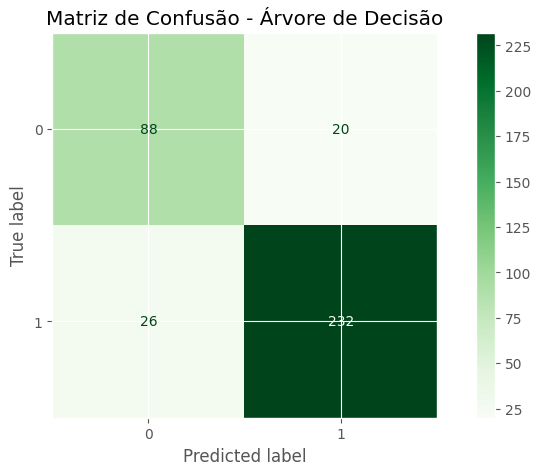

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    previsoes_tree,
    cmap="Greens"
)

plt.title("Matriz de Confusão - Árvore de Decisão")

plt.show()

# Modelo 3 - Random Forest

O Random Forest é um algoritmo baseado em um conjunto de árvores de decisão.

Ao combinar diversas árvores treinadas sobre diferentes subconjuntos dos dados, o modelo tende a reduzir o overfitting e aumentar a capacidade de generalização, sendo frequentemente utilizado em problemas de classificação.

In [32]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [33]:
previsoes_rf = modelo_rf.predict(X_test)

In [34]:
print(f"Accuracy : {accuracy_score(y_test, previsoes_rf):.4f}")
print(f"Precision: {precision_score(y_test, previsoes_rf):.4f}")
print(f"Recall   : {recall_score(y_test, previsoes_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, previsoes_rf):.4f}")

Accuracy : 0.8852
Precision: 0.9122
Recall   : 0.9264
F1 Score : 0.9192


In [35]:
print(classification_report(y_test, previsoes_rf))

              precision    recall  f1-score   support

           0       0.82      0.79      0.80       108
           1       0.91      0.93      0.92       258

    accuracy                           0.89       366
   macro avg       0.86      0.86      0.86       366
weighted avg       0.88      0.89      0.88       366



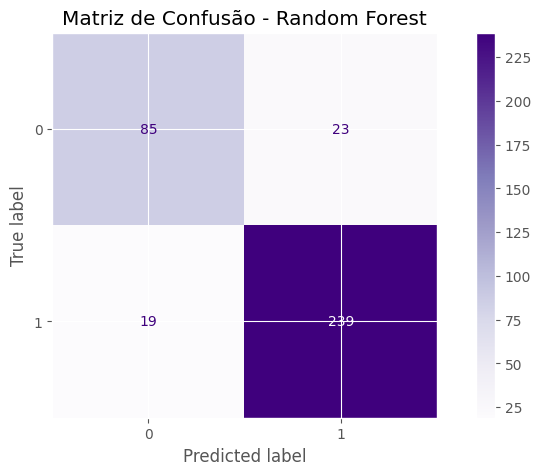

In [36]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    previsoes_rf,
    cmap="Purples"
)

plt.title("Matriz de Confusão - Random Forest")

plt.show()

# Comparação dos Modelos

Nesta etapa são comparados os resultados obtidos pelos três algoritmos de classificação utilizados no projeto.

A comparação considera as métricas de Accuracy, Precision, Recall e F1-Score.

In [37]:
comparacao = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, previsoes_lr),
        accuracy_score(y_test, previsoes_tree),
        accuracy_score(y_test, previsoes_rf)
    ],
    "Precision": [
        precision_score(y_test, previsoes_lr),
        precision_score(y_test, previsoes_tree),
        precision_score(y_test, previsoes_rf)
    ],
    "Recall": [
        recall_score(y_test, previsoes_lr),
        recall_score(y_test, previsoes_tree),
        recall_score(y_test, previsoes_rf)
    ],
    "F1-Score": [
        f1_score(y_test, previsoes_lr),
        f1_score(y_test, previsoes_tree),
        f1_score(y_test, previsoes_rf)
    ]
})

comparacao = comparacao.round(4)

comparacao

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regressão Logística,0.8415,0.8788,0.8992,0.8889
1,Árvore de Decisão,0.8743,0.9206,0.8992,0.9098
2,Random Forest,0.8852,0.9122,0.9264,0.9192


In [38]:
comparacao.sort_values(
    by="F1-Score",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.8852,0.9122,0.9264,0.9192
1,Árvore de Decisão,0.8743,0.9206,0.8992,0.9098
0,Regressão Logística,0.8415,0.8788,0.8992,0.8889


# Importância das Variáveis

O Random Forest permite calcular a importância relativa de cada variável utilizada durante o treinamento.

Essa análise auxilia na identificação dos fatores com maior influência na previsão da evasão acadêmica.

In [39]:
importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias

,Variavel,Importancia
0,TURMA,0.404327
3,TotalAulas,0.172131
6,PercentualFaltas,0.143835
4,TotalFaltas,0.108101
8,ParcelasPendentes,0.085338
7,SaldoDevedor,0.051617
1,TURNO,0.015958
9,PossuiDivida,0.011295
5,TotalFaltasJustificadas,0.007397
2,MODALIDADE,0.000000


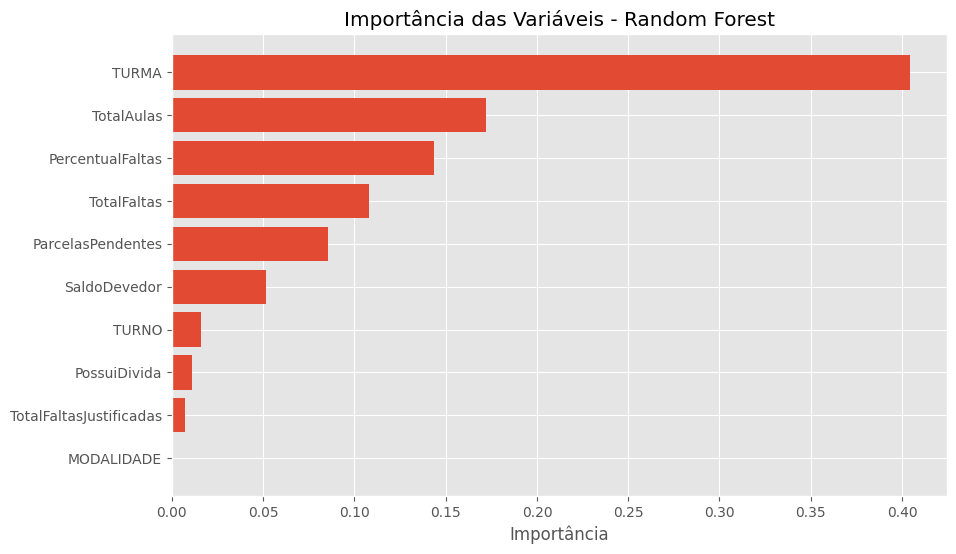

In [40]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias["Variavel"],
    importancias["Importancia"]
)

plt.gca().invert_yaxis()

plt.title("Importância das Variáveis - Random Forest")

plt.xlabel("Importância")

plt.show()

# Conclusão

Foram avaliados três algoritmos de classificação para predição da evasão acadêmica: Regressão Logística, Árvore de Decisão e Random Forest.

Os resultados demonstraram que o modelo Random Forest apresentou o melhor desempenho entre os algoritmos avaliados, alcançando aproximadamente 87% de acurácia e F1-Score superior a 90%.

Os resultados indicam que informações acadêmicas, financeiras e de frequência podem ser utilizadas para identificar alunos com maior probabilidade de evasão, permitindo que a instituição desenvolva ações preventivas de acompanhamento e permanência estudantil.

A metodologia adotada demonstrou que técnicas de Machine Learning podem apoiar a tomada de decisão institucional por meio da análise preditiva dos dados acadêmicos.

# Persistência do Modelo

Após a avaliação dos algoritmos, o Random Forest foi selecionado como o modelo com melhor desempenho.

Nesta etapa, o modelo treinado e os codificadores utilizados durante o pré-processamento são salvos para reutilização na aplicação prática, simulando um fluxo semelhante ao utilizado em ambientes de produção.

In [41]:
print("Turmas:", len(encoder_turma.classes_))
print(encoder_turma.classes_)

print()

print("Turnos:", len(encoder_turno.classes_))
print(encoder_turno.classes_)

print()

print("Modalidades:", len(encoder_modalidade.classes_))
print(encoder_modalidade.classes_)

Turmas: 180
['ADS1M19/1' 'ADS1M19/2' 'ADS1M20/1' 'ADS1M21/1' 'ADS1M21/2' 'ADS1M22/1'
 'ADS1M22/2' 'ADS1M23/1' 'ADS1M23/2' 'ADS1M24/1' 'ADS1M24/2' 'ADS1M25/1'
 'ADS1M25/2' 'ADS1M26/1' 'ADS1M26/2' 'ADS1N19/1' 'ADS1N19/2' 'ADS1N20/1'
 'ADS1N20/2' 'ADS1N21/1' 'ADS1N21/2' 'ADS1N22/1' 'ADS1N22/2' 'ADS1N23/1'
 'ADS1N23/2' 'ADS1N24/1' 'ADS1N24/2' 'ADS1N25/1' 'ADS1N25/2' 'ADS1N26/1'
 'ADS1N26/2' 'ADS2M19/1' 'ADS2M19/2' 'ADS2M20/1' 'ADS2M20/2' 'ADS2M21/1'
 'ADS2M21/2' 'ADS2M22/1' 'ADS2M22/2' 'ADS2M23/1' 'ADS2M23/2' 'ADS2M24/1'
 'ADS2M24/2' 'ADS2M25/1' 'ADS2M25/2' 'ADS2M26/1' 'ADS2M26/2' 'ADS2N19/1'
 'ADS2N19/2' 'ADS2N20/1' 'ADS2N20/2' 'ADS2N21/1' 'ADS2N21/2' 'ADS2N22/1'
 'ADS2N22/2' 'ADS2N23/1' 'ADS2N23/2' 'ADS2N24/1' 'ADS2N24/2' 'ADS2N25/1'
 'ADS2N25/2' 'ADS2N26/1' 'ADS2N26/2' 'ADS3M19/1' 'ADS3M19/2' 'ADS3M20/1'
 'ADS3M20/2' 'ADS3M21/1' 'ADS3M21/2' 'ADS3M22/1' 'ADS3M22/2' 'ADS3M23/1'
 'ADS3M23/2' 'ADS3M24/1' 'ADS3M24/2' 'ADS3M25/1' 'ADS3M25/2' 'ADS3M26/1'
 'ADS3M26/2' 'ADS3N19/1' 'ADS3N19/2' 'A

In [42]:
import joblib

pacote_modelo = {
    "modelo": modelo_rf,
    "encoder_turma": encoder_turma,
    "encoder_turno": encoder_turno,
    "encoder_modalidade": encoder_modalidade,
    "variaveis": X.columns.tolist()
}

joblib.dump(pacote_modelo, "modelo_evasao_ads.pkl")

print("Pacote do modelo salvo com sucesso!")

Pacote do modelo salvo com sucesso!


In [43]:
from google.colab import files

files.download("modelo_evasao_ads.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>